In [1]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

# Definitions

In [2]:
batch_size = 256
image_size = 324
model_image_size = 64
workers = 2
rootdir = "/Users/ishwar/Desktop/"
output_dir = "model_output_082625_2"
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

In [3]:
class Prnt(nn.Module):
    def __init__(self):
        super(Prnt, self).__init__()

    def forward(self, x):
        print(x)
        return x
    
NUM_LANDMARKS = 5

class ImgToHeatmap(nn.Module):
    def __init__(self):
        super(ImgToHeatmap, self).__init__()
        
        self.modules = []

        self.kernelSize = 5 # must be odd

        self.internal = 7
        self.layers = 10

        self.num_landmarks = NUM_LANDMARKS

        self.p_dropout = 0.2

        # cumulatively, take 4-dim vector and output 4-dim vector
        # first two dims: actual vector
        # second two dims: state vector

        self.modules.append(nn.Conv2d(3, self.internal, self.kernelSize, stride=2, \
                                      padding=(self.kernelSize-1)//2))
        for i in range(self.layers):
            self.modules.append(nn.Conv2d(self.internal, self.internal, self.kernelSize, stride=1, \
                                      padding=(self.kernelSize-1)//2))
            self.modules.append(nn.BatchNorm2d(self.internal))
            self.modules.append(nn.ReLU())
            self.modules.append(nn.Dropout(p=self.p_dropout))
            
        self.modules.append(nn.Conv2d(self.internal, self.num_landmarks, self.kernelSize, stride=1, \
                                      padding=(self.kernelSize-1)//2))
        
        self.modules.append(nn.Sigmoid())
        
        self.main = nn.Sequential(*self.modules)

    def forward(self, input):
        z = self.main(input)
        return z


In [4]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        self.kernelSize = 3
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(True)
        self.conv = nn.Conv2d(out_channels*2, out_channels, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2)
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.activation1 = nn.ReLU(True)

    def forward(self, x1, x2):
        x = self.up(x1)
        x = self.batch_norm(x)
        x = self.activation(x)
        #print(f"x.shape {x.shape}")
        x = torch.cat([x, x2], dim=1)
        #print(f"x.shape after merge: {x.shape}")
        x = self.conv(x)
        x = self.batch_norm1(x)
        x = self.activation1(x)
        return x

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()

        self.kernelSize = 3
        self.conv = nn.Conv2d(in_channels, in_channels, self.kernelSize, stride=1, \
                                padding=(self.kernelSize-1)//2)
        self.batch_norm0 = nn.BatchNorm2d(in_channels)
        self.activation0 = nn.ReLU(True)
        self.down = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(True)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm0(x)
        x = self.activation0(x)
        x = self.down(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        return x

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        self.modules = []
        self.kernelSize = 3 # must be odd
        self.num_landmarks = NUM_LANDMARKS
        self.p_dropout = 0.2

        # cumulatively, take 4-dim vector and output 4-dim vector
        # first two dims: actual vector
        # second two dims: state vector

        self.init_conv = nn.Conv2d(3, 8, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2)
        
        # downsizing
        channels = (8, 16)
        self.downsize1 = Down(channels[0], channels[1])

        channels = (16, 32)
        self.downsize2 = Down(channels[0], channels[1])

        channels = (32, 64)
        self.downsize3 = Down(channels[0], channels[1])

        channels = (64, 128)
        self.downsize4 = Down(channels[0], channels[1])

        #upsizing
        channels = (128, 64)
        self.upsize4 = Up(channels[0], channels[1])

        channels = (64, 32)
        self.upsize3 = Up(channels[0], channels[1])

        channels = (32, 16)
        self.upsize2 = Up(channels[0], channels[1])

        channels = (16, 8)
        self.upsize1 = Up(channels[0], channels[1])

        self.final_conv = nn.Conv2d(8, self.num_landmarks, self.kernelSize, stride=1, \
                                    padding=(self.kernelSize-1)//2)
        #self.final_activation = nn.Sigmoid()
        

    def forward(self, input):
        x0 = self.init_conv(input)
        #print(x0.shape)
        #print(torch.mean(torch.std(x0, axis=1)))
        x1 = self.downsize1(x0)
        #print(torch.mean(torch.std(x1, axis=1)))
        #x1 = F.dropout(x1, p=self.p_dropout)
        x2 = self.downsize2(x1)
        #print(torch.mean(torch.std(x2, axis=1)))
        #x2 = F.dropout(x2, p=self.p_dropout)
        x3 = self.downsize3(x2)
        #print(torch.mean(torch.std(x3, axis=1)))
        #x3 = F.dropout(x3, p=self.p_dropout)
        x4 = self.downsize4(x3)
        #print(torch.mean(torch.std(x4, axis=1)))
        #x4 = F.dropout(x4, p=self.p_dropout)
        x = self.upsize4(x4, x3)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = F.dropout(x, p=self.p_dropout)
        x = self.upsize3(x, x2)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = F.dropout(x, p=self.p_dropout)
        x = self.upsize2(x, x1)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = F.dropout(x, p=self.p_dropout)
        x = self.upsize1(x, x0)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = F.dropout(x, p=self.p_dropout)
        x = self.final_conv(x)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = self.final_activation(x)
        #print(torch.mean(torch.std(x, axis=1)))
        return x

In [5]:
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        #nn.init.normal_(m.weight.data, 0.0, 1/16) # not tried yet
        nn.init.normal_(m.weight.data, 0.0, weight_spread)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, weight_spread)
        nn.init.normal_(m.bias.data, 0.0, weight_spread)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [6]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(True) # Needed for reproducible resultsStop playing

Random Seed:  499


In [7]:
def coord_to_heatmap(coord_array, image_shape, sigma_in, device):
    heatmaps = torch.zeros((NUM_LANDMARKS, image_shape[1], image_shape[2]))
    for i in range(NUM_LANDMARKS):
        mu_x, mu_y = coord_array[i][0], coord_array[i][1]   # center (x,y)
        sigma = sigma_in * model_image_size / image_size

        ys = torch.arange(image_shape[1], device=device, dtype=torch.float32)
        xs = torch.arange(image_shape[2], device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')          # HxW each

        img = torch.exp(-0.5 * ((xx - mu_x)**2 + (yy - mu_y)**2) / (sigma**2))
        #img = torch.sqrt((xx - mu_x)**2 + (yy - mu_y)**2)
        # (optional) normalize to peak (1 / 1 + 1e-3)
        img = img / img.max()
        heatmaps[i] = img
    return heatmaps

In [8]:
SIGMA = 30
class FramesFromCSV(Dataset):
    def __init__(self, csv_path, images_dir, image_pattern="frame_{frame}.png", transform=None):
        """
        Args:
            csv_path: path to CSV file with header in first row
            images_dir: directory containing frame PNGs
            image_pattern: naming pattern for image files
            transform: optional torchvision transform
        """
        self.images_dir = images_dir
        self.image_pattern = image_pattern
        self.transform = transform

        # Load CSV into numpy array, skipping header
        self.data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
        # Ensure it's 2D even if only one row
        if self.data.ndim == 1:
            self.data = np.expand_dims(self.data, axis=0)

        self.frame_numbers = self.data[:, 0].astype(int)
        self.points = self.data[:, 1:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        coords = self.points[idx]

        # Load image
        img_path = os.path.join(self.images_dir, self.image_pattern.format(frame=frame_num))
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Reshape coords into N×2 array (x, y)
        coords = coords.reshape(-1, 2)
        coords_tensor = torch.tensor(coords, dtype=torch.float32)
        coords_tensor = coords_tensor * model_image_size/image_size

        return {
            "image": image,
            "points": coords_tensor,
            "heatmaps": coord_to_heatmap(coords_tensor, image.shape, SIGMA, "cpu"),
            "frame": frame_num
        }


In [9]:
dataset = FramesFromCSV(
    csv_path="plane_data/labeled_points_mega_grp.csv",
    images_dir="outp",
    image_pattern="frame_{frame}.png",
    transform=transforms.Compose([
                               transforms.Resize(model_image_size),
                               transforms.ToTensor(),
                           ])
)

In [10]:
print(dataset[11])

{'image': tensor([[[0.2471, 0.2471, 0.2471,  ..., 0.2588, 0.2588, 0.2588],
         [0.2471, 0.2471, 0.2471,  ..., 0.2588, 0.2588, 0.2667],
         [0.2471, 0.2471, 0.2471,  ..., 0.2588, 0.2588, 0.2588],
         ...,
         [0.2824, 0.2824, 0.2824,  ..., 0.3020, 0.3020, 0.3020],
         [0.2824, 0.2824, 0.2824,  ..., 0.3020, 0.3020, 0.3020],
         [0.2824, 0.2824, 0.2824,  ..., 0.2980, 0.2980, 0.2980]],

        [[0.3765, 0.3765, 0.3765,  ..., 0.3725, 0.3725, 0.3686],
         [0.3765, 0.3765, 0.3765,  ..., 0.3725, 0.3569, 0.3412],
         [0.3765, 0.3765, 0.3765,  ..., 0.3725, 0.3725, 0.3686],
         ...,
         [0.4039, 0.4039, 0.4039,  ..., 0.4196, 0.4196, 0.4235],
         [0.4039, 0.4039, 0.4039,  ..., 0.4196, 0.4196, 0.4235],
         [0.4039, 0.4039, 0.4039,  ..., 0.4235, 0.4235, 0.4235]],

        [[0.5373, 0.5373, 0.5373,  ..., 0.5569, 0.5686, 0.5922],
         [0.5373, 0.5373, 0.5373,  ..., 0.5569, 0.6392, 0.7020],
         [0.5373, 0.5373, 0.5373,  ..., 0.5569, 

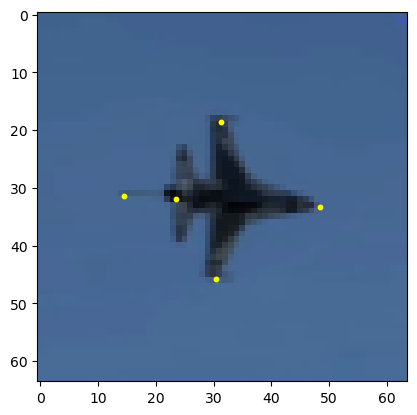

In [11]:
IMG_IDX = 790
plt.imshow(torch.permute(dataset[IMG_IDX]['image'], (1, 2, 0)))
# Unpack points into two lists: xs, ys
xs = [p[0] for p in dataset[IMG_IDX]['points']]
ys = [p[1] for p in dataset[IMG_IDX]['points']]
# Plot points as red circles
plt.scatter(xs, ys, c='yellow', s=10)  # s = point size

tensor(4.2492e-22) tensor(1.)
torch.Size([5, 64, 64])


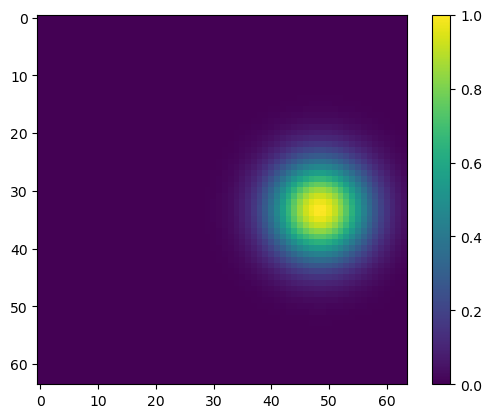

In [12]:
print(torch.min(dataset[IMG_IDX]['heatmaps']), torch.max(dataset[IMG_IDX]['heatmaps']))
print(dataset[IMG_IDX]['heatmaps'].shape)
plt.imshow(dataset[IMG_IDX]['heatmaps'][0])
plt.colorbar()

tensor(4.2492e-22) tensor(1.)


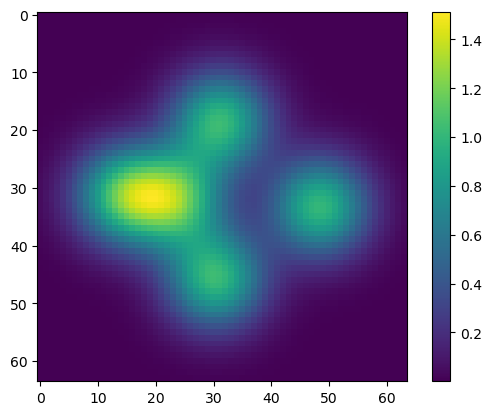

In [13]:
print(torch.min(dataset[IMG_IDX]['heatmaps']), torch.max(dataset[IMG_IDX]['heatmaps']))
plt.imshow(torch.sum(dataset[IMG_IDX]['heatmaps'], axis=0))
plt.colorbar()

In [14]:
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

for batch in loader:
    print(batch["frame"])
    print(batch["points"].shape)  # (B, N, 2)
    break

tensor([   0,    1,   29,   50,   63,   79,  103,  139,  181,  216,  248,  273,
         296,  325,  347,  366,  378,  420,  441,  480,  521,  557,  620,  743,
         831,  857,  879,  929, 1015, 1056, 1065, 1077, 1080, 1082, 1084, 1086,
        1088, 1090, 1095, 1102, 1105, 1111, 1122, 1130, 1141, 1155, 1165, 1187,
        1198, 1218, 1227, 1240, 1248, 1255, 1269, 1287, 1302, 1324, 1350, 1360,
        1372, 1392, 1402, 1431, 1444, 1446, 1450, 1453, 1457, 1463, 1466, 1469,
        1473, 1479, 1485, 1489, 1496, 1499, 1503, 1511, 1520, 1540, 1549, 1566,
        1572, 1579, 1601, 1621, 1641, 1653, 1663, 1676, 1686, 1709, 1784, 1862,
        1884, 1908, 1929, 1962, 2045, 2074, 2087, 2094, 2104, 2115, 2120, 2126,
        2135, 2148, 2169, 2205, 2224, 2245, 2327, 2375, 2422, 2468, 2505, 2516,
        2575, 2720, 2766, 2810, 2873, 2903, 2919, 2961, 3002, 3071, 3111, 3142,
        3227, 3263, 3292, 3364, 3380, 3400, 3420, 3448, 3552, 3570, 3680, 3719,
        3889, 3951, 4047, 4115, 4182, 42

In [ ]:
trial_number = 0

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

# if not os.path.exists(datapath+"/trial_"+str(trial_number)):
#     os.mkdir(datapath+"/trial_"+str(trial_number))

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print("device: ", device)

#print("Instantiating ImgToHeatmap")
print("Instantiating UNet")
# Create the generator
#model = ImgToHeatmap().to(device, dtype=torch.float32)
model = UNet().to(device, dtype=torch.float32)
model.apply(weights_init)
print(model)

# Setup Adam optimizers for both G and D
optimizer = optim.Adam(model.parameters(), lr=0.0005, betas=(0.5, 0.999))
print("Model optimizer: \n", optimizer)

#criterion = nn.BCELoss()
criterion = nn.MSELoss()
error_kind = "MSE"

clipper = WeightConstraint()

device:  cpu
Instantiating UNet
UNet(
  (init_conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downsize1): Down(
    (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
  )
  (downsize2): Down(
    (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [16]:
iters = 0
epoch = 0
num_epochs = 500
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

losses = []

example_idx = 110

In [ ]:
# train the model
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#train_D_only = False
#train_G_only = False
print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    should_break = False
    
    for i, data in enumerate(loader, 0):
        print("Epoch\t"+str(epoch)+", batch\t"+str(i)+".", end="\n")
         # Check how the generator is doing by saving G's output on fixed_noise
        #if (epoch % k == 0) and (i == len(dataloader)-1):
        data_input = data['image']
        output = data['heatmaps']

        data_input = data_input.to(device, dtype=torch.float32)
        batch_size = data_input.size(0)
        print("Batch size: ", batch_size)
        print(data_input.dtype)

        # print(dataseq.shape)

        heatmap_predicted = model(data_input) # outputs logits

        model.zero_grad()

        y_err = 1
        # for i in range(NUM_LANDMARKS):
        #     print(torch.argmax(torch.reshape(output[0, i, :, :], (model_image_size*model_image_size,))))
        #print(data['points'])
        err = criterion(heatmap_predicted.flatten(), output.flatten())
        err.backward()

        optimizer.step()

        #time.sleep(1.00)

        print(f"\t {error_kind}: {err.item()}")
        losses.append((epoch, i, iters, {f"{error_kind}_error": err.item()},
                                        {f"y_{error_kind}_error": y_err} ))

        iters += 1
    
        # if iters > 1000: # stop to quickly see results
        #     should_break = True
        #     break
    
    if should_break:
        break

    if (epoch+1) % 1 == 0:
        print(f"Saving results for example index {example_idx}")
        # output example output from model
        example_point = dataset[example_idx]
        image = torch.permute(example_point['image'], (1, 2, 0))
        plt.imshow(image.numpy())
        plt.savefig(f"{output_dir}/epoch{epoch}_in.png")
        plt.clf()

        input_example = example_point['image'].to(dtype=torch.float32)
        print(torch.min(input_example), torch.max(input_example))
        print(input_example.shape)
        heatmap_pred = model( torch.stack((input_example,)) ).detach()
        heatmap_actual = example_point['heatmaps']
        print(heatmap_pred.shape)
        for i in range(NUM_LANDMARKS):
            plt.imshow(heatmap_pred.numpy()[0][i], vmin=0, vmax=1)
            plt.colorbar()
            plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}.png")
            plt.clf()
            plt.imshow(heatmap_actual.numpy()[i], vmin=0, vmax=1)
            plt.colorbar()
            plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_real.png")
            plt.clf()

    epoch += 1
    SIGMA = ((SIGMA - 4) * 0.997) + 4

In [ ]:
num_epochs = 2000

In [ ]:
losses

In [ ]:
losses[0]

Text(0, 0.5, 'Log loss')

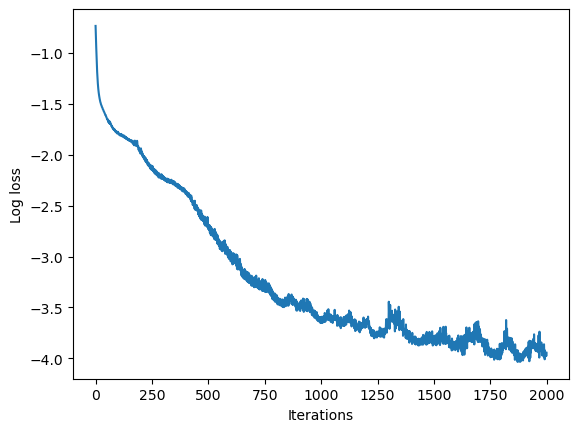

In [ ]:
import math
plt.plot([x[2] for x in losses], [math.log(x[3][f"{error_kind}_error"], 10) for x in losses])
plt.xlabel("Iterations")
plt.ylabel("Log loss")

In [ ]:
losses[-1][3][f"{error_kind}_error"]

0.00011381893273210153

In [ ]:
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': losses,
            }, f"{output_dir}/info_model_082525_500.pt")

In [ ]:
model.eval()

UNet(
  (init_conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downsize1): Down(
    (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
  )
  (downsize2): Down(
    (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace

In [ ]:
model_dict = torch.load(f"{output_dir}/info_model_082525_500.pt", weights_only=True)
model_dict['loss'][-1]

In [18]:
model_loaded = UNet()
model_loaded.load_state_dict(model_dict['model_state_dict'])
model_loaded.eval()
model_loaded

UNet(
  (init_conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downsize1): Down(
    (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
  )
  (downsize2): Down(
    (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batch_norm0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation0): ReLU(inplace=True)
    (down): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace

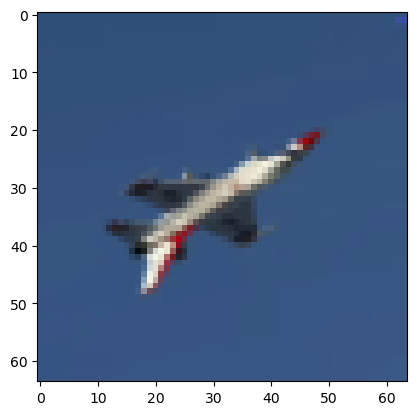

In [19]:
example_point = dataset[590]
image = torch.permute(example_point['image'], (1, 2, 0))
plt.imshow(image.numpy())

tensor(0.0235) tensor(0.9608)
torch.Size([3, 64, 64])
torch.Size([1, 5, 64, 64])


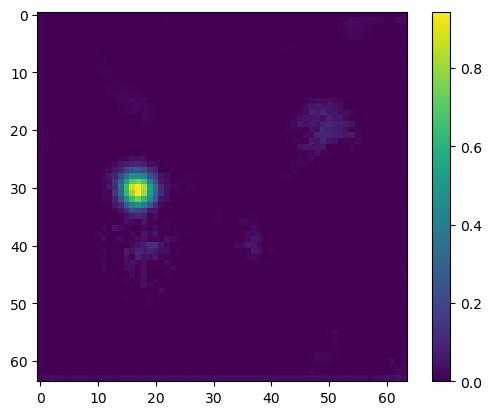

In [20]:
input_example = example_point['image'].to(dtype=torch.float32)
print(torch.min(input_example), torch.max(input_example))
print(input_example.shape)
heatmap_pred = model_loaded( torch.stack((input_example,)) ).detach()
print(heatmap_pred.shape)
plt.imshow(heatmap_pred.numpy()[0][1], vmin=0)
plt.colorbar()

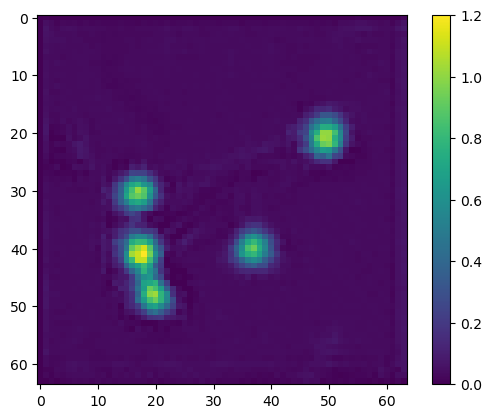

In [21]:
plt.imshow(torch.sum(heatmap_pred[0], dim=0).numpy(), vmin=0)
plt.colorbar()

(array([2.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 5.000e+00, 9.000e+00,
        1.600e+01, 2.400e+01, 1.400e+01, 2.800e+01, 3.400e+01, 2.700e+01,
        3.700e+01, 3.700e+01, 2.900e+01, 2.600e+01, 2.200e+01, 2.900e+01,
        2.800e+01, 3.200e+01, 3.500e+01, 2.800e+01, 3.000e+01, 2.800e+01,
        2.400e+01, 2.100e+01, 2.200e+01, 3.000e+01, 2.000e+01, 2.500e+01,
        2.700e+01, 2.100e+01, 2.300e+01, 2.600e+01, 2.900e+01, 3.000e+01,
        2.300e+01, 2.100e+01, 2.400e+01, 2.900e+01, 3.400e+01, 1.900e+01,
        3.700e+01, 2.800e+01, 2.200e+01, 3.500e+01, 2.000e+01, 2.800e+01,
        3.900e+01, 3.900e+01, 2.900e+01, 3.600e+01, 4.100e+01, 3.400e+01,
        4.600e+01, 3.600e+01, 3.200e+01, 3.900e+01, 4.600e+01, 3.700e+01,
        5.000e+01, 4.800e+01, 5.100e+01, 4.100e+01, 5.900e+01, 5.800e+01,
        6.500e+01, 6.400e+01, 6.700e+01, 7.500e+01, 7.100e+01, 9.400e+01,
        8.600e+01, 9.800e+01, 1.110e+02, 1.250e+02, 1.490e+02, 1.800e+02,
        2.270e+02, 3.870e+02, 1.583e+0

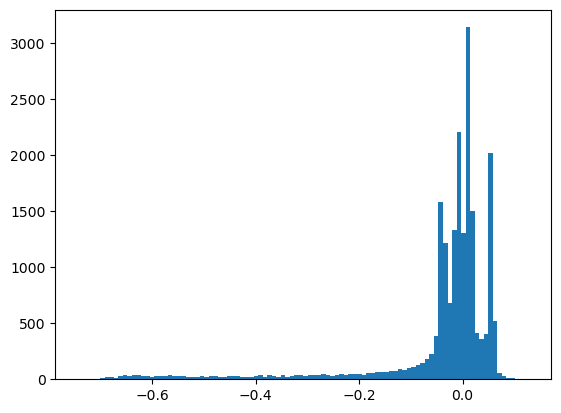

In [22]:
plt.hist((heatmap_pred - example_point['heatmaps']).detach().numpy().flatten(), bins=100)

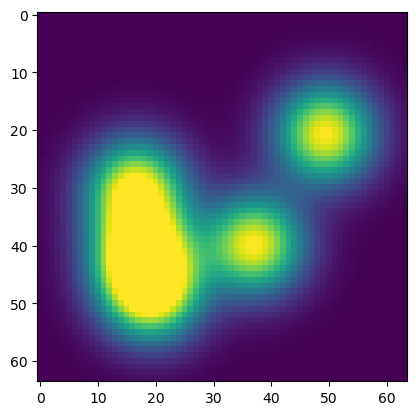

In [23]:
plt.imshow(np.sum(example_point['heatmaps'].numpy(), axis=0), vmin=0, vmax=1)

In [24]:
import frame_manager
import importlib
importlib.reload(frame_manager)

<module 'frame_manager' from '/Users/ishwar/Desktop/Aero_ML/frame_manager.py'>

In [25]:
SMOOTH_CONST = 1
# ---------- Main runner ----------
@torch.inference_mode()
def run_video_demo(model, source=0, device=None, window_name="Landmark Demo"):
    """
    source: 0 for webcam, or path to video file.
    model: a loaded torch.nn.Module that outputs heatmaps (B,C,Hh,Wh)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    t_prev = time.time()
    fps_ema = None

    try:
        while True:
            ok, frame = cap.read()
            if not ok: break

            # Keep a copy for drawing at native res
            out_frame = frame.copy()

            # Preprocess & infer
            tin, orig_wh = preprocess_frame(frame, device)
            # Optional: mixed precision for speed on GPU
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = model(tin)                 # expect (1, C, Hh, Wh)
            if pred.dim() == 5: pred = pred[0]    # in case model returns (pred, aux)
            if pred.shape[0] == 1: pred = pred    # (1,C,Hh,Wh)
            _, C, Hh, Wh = pred.shape

            # Get coords in model-input space
            xs_in, ys_in = heatmaps_to_coords(pred)      # each (1,C)
            xs_in, ys_in = xs_in[0], ys_in[0]            # (C,)

            # Draw
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # FPS
            t_now = time.time()
            fps = 1.0 / max(t_now - t_prev, 1e-6)
            fps_ema = fps if fps_ema is None else 0.9*fps_ema + 0.1*fps
            t_prev = t_now
            put_fps(out_frame, fps_ema)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):  # ESC or q
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()


class LatestFrameGrabber:
    """Continuously grabs frames on a background thread and keeps only the most recent one."""
    def __init__(self, source=0):
        self.cap = cv2.VideoCapture(source)
        if not self.cap.isOpened():
            raise RuntimeError(f"Could not open video source: {source}")
        # Best-effort: keep tiny buffer (works on some backends; harmless otherwise)
        try:
            self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        except Exception:
            pass
        self.lock = threading.Lock()
        self.frame = None
        self.stopped = False
        self.t = threading.Thread(target=self._update, daemon=True)
        self.t.start()

    def _update(self):
        while not self.stopped:
            ok, f = self.cap.read()
            if not ok:
                self.stopped = True
                break
            with self.lock:
                self.frame = f

    def read(self):
        with self.lock:
            return None if self.frame is None else self.frame.copy()

    def release(self):
        self.stopped = True
        try:
            self.t.join(timeout=1.0)
        except Exception:
            pass
        self.cap.release()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_fixed_rate(model, source=0, device=None, window_name="Landmark Demo",
                              sample_hz=15.0, show_fps=True):
    """
    Samples the *latest* frame every 1/sample_hz seconds, runs inference on that frame,
    and displays only those results. Drops frames between ticks to avoid latency buildup.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    grab = LatestFrameGrabber(source)  # from previous code: grabs frames on a thread
    dt = 1.0 / float(max(sample_hz, 1e-6))
    next_t = time.perf_counter()  # monotonic clock

    disp_fps_ema = None
    try:
        while True:
            now = time.perf_counter()
            # sleep until the next scheduled tick (keeps rate steady, avoids drift)
            if now < next_t:
                time.sleep(next_t - now)
                continue
            # schedule the following tick
            next_t += dt

            t0 = time.perf_counter()
            frame = grab.read()
            if frame is None:
                # No new frame yet; skip this tick but keep schedule
                continue

            out_frame = frame.copy()

            # Preprocess & infer on the ticked frame
            tin, orig_wh = preprocess_frame(frame, device)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                tin = tin.to(dtype=torch.float32)
                pred = model(tin)  # (1, C, Hh, Wh)

            xs_in, ys_in = heatmaps_to_coords(pred)   # each (1, C) in model-input coords
            xs_in, ys_in = xs_in[0], ys_in[0]
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # Display + UI FPS (UI FPS may be ~ sample_hz)
            t1 = time.perf_counter()
            ui_fps = 1.0 / max(t1 - t0, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                put_fps(out_frame, disp_fps_ema)
                cv2.putText(out_frame, f"Sample: {sample_hz:.1f} Hz",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # If inference was slower than dt, catch the schedule up (drop extra ticks)
            # so next tick isn't delayed by accumulated lag.
            now2 = time.perf_counter()
            while next_t < now2 - 1e-4:
                next_t += dt
    finally:
        grab.release()
        cv2.destroyAllWindows()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_auto(model, source=0, device=None, window_name="Landmark Demo",
                        sample_hz=15.0, show_fps=True):
    """
    - If source is webcam (fps not available) → run at fixed sample_hz (e.g. 15 Hz).
    - If source is video file (fps available) → throttle playback to the file's FPS.
    """

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    # Try to read FPS from file
    fps_file = cap.get(cv2.CAP_PROP_FPS)
    if fps_file is None or fps_file <= 1e-2:  # webcams often report 0
        mode = "webcam"
        dt = 1.0 / float(max(sample_hz, 1e-6))   # fixed rate
        print(f"[INFO] Webcam mode: target {sample_hz} Hz")
    else:
        mode = "file"
        dt = 1.0 / fps_file
        print(f"[INFO] Video file mode: target {fps_file:.2f} FPS")

    next_t = time.perf_counter()
    disp_fps_ema = None

    prev_xs_in_smooth, prev_ys_in_smooth = None, None

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            out_frame = frame.copy()

            # preprocess
            tin, orig_wh = frame_manager.preprocess_frame(frame, device)

            # inference
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = model(tin)  # (1, C, H, W)
            xs_in, ys_in = frame_manager.heatmaps_to_coords(pred)
            xs_in, ys_in = xs_in[0], ys_in[0]
            if prev_xs_in_smooth is None:
                xs_in_smooth, ys_in_smooth = xs_in, ys_in
            else:
                xs_in_smooth, ys_in_smooth = xs_in*SMOOTH_CONST + prev_xs_in_smooth*(1-SMOOTH_CONST), ys_in*SMOOTH_CONST + prev_ys_in_smooth*(1-SMOOTH_CONST)
            frame_manager.draw_points(out_frame, xs_in_smooth, ys_in_smooth, orig_wh)
            prev_xs_in_smooth, prev_ys_in_smooth = xs_in_smooth, ys_in_smooth

            # UI FPS
            now = time.perf_counter()
            ui_fps = 1.0 / max(now - next_t + dt, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                frame_manager.put_fps(out_frame, disp_fps_ema)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # pacing
            if mode == "webcam":
                # sleep until next scheduled tick
                now = time.perf_counter()
                if now < next_t:
                    time.sleep(next_t - now)
                next_t += dt
            else:  # file
                wait_ms = int(max(1, dt * 1000))
                if cv2.waitKey(wait_ms) & 0xFF in (27, ord('q')):
                    break

    finally:
        cap.release()
        cv2.destroyAllWindows()


In [26]:
# or a file:
run_video_demo_auto(model_loaded, source="plane_2.mov", sample_hz=60.0)

[INFO] Video file mode: target 59.85 FPS


2025-11-22 14:25:48.509 python[2124:109264] +[IMKClient subclass]: chose IMKClient_Modern
2025-11-22 14:25:48.509 python[2124:109264] +[IMKInputSession subclass]: chose IMKInputSession_Modern


KeyboardInterrupt: 